In [1]:
DATA_PATH = r"../../data/diabetes/diabetes.csv"

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import kendalltau
import copy

import shap

import time

c:\Users\uiv09218\AppData\Local\miniforge3\envs\xai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

In [3]:
df = pd.read_csv(DATA_PATH, header=0)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df = df.sample(frac=1).reset_index(drop=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,94,76,18,66,31.6,0.649,23,0
1,1,108,88,19,0,27.1,0.400,24,0
2,1,87,78,27,32,34.6,0.101,22,0
3,0,118,84,47,230,45.8,0.551,31,1
4,0,101,64,17,0,21.0,0.252,21,0
...,...,...,...,...,...,...,...,...,...
763,7,133,88,15,155,32.4,0.262,37,0
764,3,148,66,25,0,32.5,0.256,22,0
765,1,97,70,40,0,38.1,0.218,30,0
766,3,116,74,15,105,26.3,0.107,24,0


In [8]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,4,128,70,0,0,34.3,0.303,24
618,0,167,0,0,0,32.3,0.839,30
346,8,99,84,0,0,35.4,0.388,50
294,4,120,68,0,0,29.6,0.709,34
231,2,129,74,26,205,33.2,0.591,25
...,...,...,...,...,...,...,...,...
71,1,128,98,41,58,32.0,1.321,33
106,4,94,65,22,0,24.7,0.148,21
270,1,109,38,18,120,23.1,0.407,26
435,1,81,72,18,40,26.6,0.283,24


---

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=3368494378)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
rf.score(X_test, y_test)

0.8051948051948052

---

X_stds

mutations = []

for _ in range(1000):
    mutations.append(np.random.normal(0, X_stds, size=X_train.values.shape).std(axis=0))

np_mutations = np.array(mutations).mean(axis=0)

np_mutations

In [12]:
def produce_shap_explanations(
    explainer: shap.Explainer,
    dataset: np.ndarray
) -> np.ndarray:
    """
    Produces an array of SHAP explanations for each instance of the given dataset using
    the provided SHAP explainer. The explanations are determined w.r.t. the class 1.

    Parameters
    ----------
    explainer : shap.Explainer
        A SHAP explainer object that can compute SHAP values for instances.

    dataset : np.ndarray
        A numpy array of shape (n_samples, n_features) containing the instances for 
        which local explanations are to be generated.

    Returns
    -------
    np.ndarray
        A 2D numpy array of shape (n_samples, n_features) where each row corresponds to
        the SHAP values for a single instance in the dataset.
    """
    assert isinstance(explainer, shap.Explainer)
    assert isinstance(dataset, np.ndarray)
    assert dataset.ndim == 2

    explanations = explainer(dataset).values[:, :, 1]

    return explanations

In [13]:
def manhattan_distance(
    vec1: np.ndarray,
    vec2: np.ndarray
) -> float:
    """
    Computes the Manhattan distance between two vectors.

    Parameters
    ----------
    vec1 (np.ndarray):
        A 1D numpy array representing the first vector of explanation importance values.

    vec2 (np.ndarray):
        A 1D numpy array representing the second vector of explanation importance values.

    Returns
    -------
    float:
        The computed Manhattan distance between the two vectors.
    """
    assert isinstance(vec1, np.ndarray)
    assert isinstance(vec2, np.ndarray)
    assert vec1.shape == vec2.shape

    return np.sum(np.abs(vec1 - vec2), axis=-1)

In [14]:
def kendall_tau_distance(
    vec1: np.ndarray, 
    vec2: np.ndarray
) -> float:
    """
    Computes the ranking indices of the given vectors to sort them ascensingly and
    then calculates the Kendall Tau distance between the two rankings using the
    scipy.stats.kendalltau() function.
    Since the function returns a similarity score in the range [-1, 1], it is converted
    to a distance metric in the range [0, 1], i.e. [unsimilar, similar], by computing 
    (1 - tau) / 2.

    Parameters
    ----------
    vec1 (np.ndarray):
        A 1D numpy array representing the first vector of explanation importance values.

    vec2 (np.ndarray):
        A 1D numpy array representing the second vector of explanation importance values.

    Returns
    -------
    float:
        The computed Kendall Tau distance between the two vectors.
    """
    assert isinstance(vec1, np.ndarray)
    assert isinstance(vec2, np.ndarray)
    assert vec1.shape == vec2.shape

    # produce rankings
    vec1_ranking = np.argsort(vec1, axis=-1)
    vec2_ranking = np.argsort(vec2, axis=-1)

    # compute kendall tau distance for each instance
    taus = np.array([
        kendalltau(vec1_ranking[i], vec2_ranking[i])[0] 
        for i in range(vec1.shape[0])
    ])

    return (1 - taus) / 2

In [ ]:
def manipulation_loss(
    explanation_importance_values = (None, None),
    distance_fn = None,
    order_ranking_fn = None,
    weights = (0.5, 0.5)
) -> float:
    """
    Produces a loss value based on a weighted combination of a distance function and an order ranking
    function. The functions are applied to the explanation importance values from an explainability 
    method evaluating a data instance before and after a manipulation.

    Parameters
    ----------
    explanation_importance_values (tuple):
        A tuple containing two elements:
        - The importance values before the manipulation attack for every data feature.
        - The importance values after the manipulation attack for every data feature.

    distance_fn (callable):
        A function that computes the distance between two vectors of explanation importance values,
        e.g., L1 or L2 distance.

    order_ranking_fn (callable):
        A function that computes a ranking-based metric, e.g. Kendall Tau distance.

    weights (tuple):
        A tuple containing two weights (w1, w2) that determine the contribution of the distance
        function and the order ranking function to the final loss value respectively.

    Returns
    -------
    float:
        The computed manipulation loss value.
    """
    assert isinstance(explanation_importance_values, tuple)
    assert len(explanation_importance_values) == 2
    assert explanation_importance_values[0] is not None
    assert explanation_importance_values[1] is not None
    assert distance_fn is not None
    assert order_ranking_fn is not None
    assert len(weights) == 2
    assert all(isinstance(w, (int, float)) and 0 <= w for w in weights)

    # produce distance metrics in [0, infinity)
    explanation_distance = distance_fn(
        explanation_importance_values[0],
        explanation_importance_values[1]
    )

    # transform the distance to a [0, 1] range
    distance_transform = lambda x: - (1 / (x + 1)) + 1
    explanation_distance = distance_transform(explanation_distance)

    # produce order ranking distance in [0, 1]
    order_ranking_distance = order_ranking_fn(
        explanation_importance_values[0],
        explanation_importance_values[1]
    )

    return weights[0] * explanation_distance + \
           weights[1] * order_ranking_distance

In [17]:
def explanation_loss(
    mutation_explanations: np.ndarray,
    reference_explanations: np.ndarray,
) -> np.ndarray:
    """
    Computes the loss values for a mutated individual based on the manipulation loss
    between the explanation importance values before and after the mutation.
    The used distance function is the Manhattan distance and the order ranking function
    is the Kendall Tau distance.

    Parameters
    ----------
    mutation_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the explanation
        importance values for the mutated individual.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the explanation
        importance values for the reference individual.

    Returns
    -------
    np.ndarray:
        A 1D numpy array of shape (n_samples,) containing the computed loss values.
    """
    loss = manipulation_loss(
        explanation_importance_values = (
            reference_explanations,
            mutation_explanations
        ),
        distance_fn = manhattan_distance,
        order_ranking_fn = kendall_tau_distance,
        weights = (1.0, 1.0)
    )

    return loss

In [18]:
class Individual:
    def __init__(
        self,
        data: np.ndarray,
        mutation_rate: float,
        mutation_stds: np.ndarray
    ):
        self.data = data
        self.mutation_rate = mutation_rate
        self.mutation_stds = mutation_stds

    def mutate(
        self,
        X_min: np.ndarray,
        X_max: np.ndarray,
        X_cat: list
    ):
        """
        Mutates the individual data instance by applying N(0, mutation_stds[i]) gaussian white
        noise mutations to each continuous feature and another categorical value to each 
        categorical feature with the individuals given mutation probability.
        The mutated data is clipped to the provided feature bounds.

        Parameters
        ----------
        X_min (np.ndarray):
            A 1D numpy array representing the minimum bounds for each feature.

        X_max (np.ndarray):
            A 1D numpy array representing the maximum bounds for each feature.

        X_cat (list):
            A list of numpy arrays representing the possible categories for a categorical
            feature or None if the feature is continuous. The length of the list should be
            equal to the number of features in the individual.
        """
        assert isinstance(X_min, np.ndarray)
        assert isinstance(X_max, np.ndarray)
        assert X_min.ndim == 1
        assert X_max.ndim == 1
        assert X_min.shape == X_max.shape
        assert X_min.shape[0] == self.data.shape[1]
        assert isinstance(X_cat, list)
        assert len(X_cat) == self.data.shape[1]
        assert all(isinstance(cat, np.ndarray) or cat is None for cat in X_cat)

        # create gaussian mutations with respective stds
        for feature in range(self.data.shape[1]):
            # create a mutation mask
            mutation_mask = (
                np.random.rand(
                    self.data.shape[0]
                ) < self.mutation_rate
            )
            
            # categorical feature mutation
            if X_cat[feature] is not None:
                mutation_categories = np.random.choice(
                    X_cat[feature],
                    size=self.data.shape[0]
                )

                # apply mutations according to the mask
                self.data[mutation_mask, feature] = mutation_categories[mutation_mask]
            # continuous feature mutation
            else:
                mutations = np.random.normal(
                    0,
                    self.mutation_stds[feature],
                    size=self.data.shape[0]
                )

                # apply mutations according to the mask
                self.data[mutation_mask, feature] += mutations[mutation_mask]

        # clip the mutated data to the feature bounds
        self.data = np.clip(
            self.data,
            X_min,
            X_max
        )

    def fitness(
        self,
        explainer: shap.Explainer,
        reference_explanations: np.ndarray
    ) -> tuple[float, float]:
        """
        Calculates the performance measures for a given individual dataset by producing
        local SHAP explanations and comparing them to reference explanations.
        The individual's instance explanation losses are averaged to produce a single loss value.
        And the fitness score is computed as 1/(mean(loss) + 1) to produce a fitness measure 
        between 0 and 1.

        Parameters
        ----------
        explainer (shap.Explainer):
            A SHAP explainer object that can compute SHAP values for instances.

        reference_explanations (np.ndarray):
            A 2D numpy array of shape (n_samples, n_features) containing the reference
            explanation importance values for comparison.

        Returns
        -------
        tuple:
            A tuple containing:
            - The manipulation loss value (float) averaged over all individuals.
            - The fitness score (float) computed as 1/(mean(loss) + 1) to produce a fitness 
            measure between 0 and 1.
        """
        assert self.data.ndim == 2
        assert isinstance(explainer, shap.Explainer)
        assert isinstance(reference_explanations, np.ndarray)
        assert self.data.shape == reference_explanations.shape

        # produce SHAP explanations for every instance
        mutation_explanations = produce_shap_explanations(
            explainer,
            self.data
        )

        # calculate the fitness for every instance
        loss = explanation_loss(
            mutation_explanations,
            reference_explanations
        )

        return loss.mean(), 1/(loss.mean() + 1)

In [19]:
def init_population(
    reference_data: pd.DataFrame,
    cat_mask: list = None,
    population_size: int = 50,
    initial_mutation_rate: float = 0.3,
) -> list[Individual]:
    """
    Initilizes a population of n individuals by mutating copies of the provided reference data.

    Parameters
    ----------
    reference_data (pd.DataFrame):
        A pandas DataFrame of shape (n_samples, n_features) representing the reference data
        for the individuals to be mutated for the population initialization.

    cat_mask (list):
        A list of booleans indicating whether a feature is categorical (True) or continuous (False).

    n_population (int):
        The number of individuals to initialize the population with.

    initial_mutation_rate (float):
        The initial mutation rate to use for the individuals in the population. This rate is used
        to control the amount of mutation applied to each individual's data during initialization.

    Returns
    -------
    list[Individual]:
        A population of mutated individual objects with data of shape (n_samples, n_features).
    """
    assert isinstance(reference_data, pd.DataFrame)
    assert isinstance(cat_mask, list)
    assert len(cat_mask) == reference_data.shape[1]
    assert all(isinstance(is_cat, bool) for is_cat in cat_mask)
    assert isinstance(population_size, int)
    assert population_size > 0
    assert isinstance(initial_mutation_rate, float)
    assert 0 < initial_mutation_rate <= 1

    population = []

    # determine random mutation rates for each individual
    mutation_rates = np.clip(np.random.normal(
        loc=initial_mutation_rate, 
        scale=0.05,
        size=population_size
    ), 0, 0.9999)

    for i in range(population_size):
        individual_data = reference_data.copy(deep=True)
        individual = Individual(
            data = individual_data.values,
            mutation_rate = mutation_rates[i],
            mutation_stds = np.full(shape=(reference_data.shape[1],), fill_value=0.1)
        )
        individual.mutate(
            X_min = reference_data.min().values,
            X_max = reference_data.max().values,
            X_cat = [
                np.unique(reference_data.iloc[:, feature]) if (
                    cat_mask[feature]
                ) else (
                    None
                ) for feature in range(reference_data.shape[1])
            ]
        )

        population.append(individual)

    return population

In [20]:
def population_fitness(
    population: list[Individual],
    explainer: shap.Explainer,
    reference_explanations: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculates the performance measures for a given population of individuals by producing
    SHAP explanations and comparing them to reference explanations.
    Each individual's instance explanation losses are averaged to produce a single loss value.
    And the fitness scores are computed as 1/(mean(loss) + 1) to produce a fitness measure
    between 0 and 1.

    Parameters
    ----------
    population (list[Individual]):
        A list of individuals, each represented as an Individual object.

    explainer (shap.Explainer):
        A SHAP explainer object that can compute SHAP values for instances.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the reference
        explanation importance values for comparison.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]:
        A tuple containing two elements:
        - A 1D numpy array of shape (n_individuals,) containing the manipulation loss values
          averaged for each individual.
        - A 1D numpy array of shape (n_individuals,) containing the fitness scores computed
          as 1/(mean(loss) + 1) to produce a fitness measure between 0 and 1.
    """
    assert isinstance(population, list)
    assert all(isinstance(individual, Individual) for individual in population)
    assert all(individual.data.ndim == 2 for individual in population)
    assert isinstance(reference_explanations, np.ndarray)
    assert reference_explanations.ndim == 2
    assert all(
        individual.data.shape == reference_explanations.shape
        for individual in population
    )
    assert isinstance(explainer, shap.Explainer)

    n_pop = len(population)

    start_time = time.time()

    # unify all individuals in a single array without adding a new axis
    pop = np.concatenate([individual.data for individual in population])

    print(f"Concatenating population took {time.time() - start_time} seconds.")
    section_time = time.time()
    
    # produce SHAP explanations for the entire population
    explanations = produce_shap_explanations(
        explainer,
        pop
    )

    print(f"Producing SHAP explanations for the population took {time.time() - section_time} seconds.")
    section_time = time.time()

    # repeat the reference explanations for all individuals
    # to match the above explanations shape
    reference_explanations_rep = np.tile(
        reference_explanations,
        (n_pop, 1)
    )

    print(f"Repeating reference explanations took {time.time() - section_time} seconds.")
    section_time = time.time()

    # calculate the loss for all individuals
    losses = explanation_loss(
        explanations,
        reference_explanations_rep
    )

    print(f"Calculating explanation losses for the population took {time.time() - section_time} seconds.")
    section_time = time.time()

    # determine quality measures for each individual
    mean_losses = losses.reshape(n_pop, -1).mean(axis=1)
    fitnesses = 1/(mean_losses + 1)

    print(f"Calculating mean losses and fitnesses took {time.time() - section_time} seconds.")

    return mean_losses, fitnesses

In [21]:
def select_elitists(
    population: list[Individual],
    fitnesses: np.ndarray,
    elite_prop: float = 0.05
) -> list[Individual]:
    """
    Selects the top `elite_prop` proportion of individuals from the population based on their
    fitness scores.

    Parameters
    ----------
    population (list[Individual]):
        A list of individuals, each represented as an Individual object.

    fitnesses (np.ndarray):
        A 1D numpy array of shape (n_individuals,) containing the fitness scores for each individual.

    elite_prop (float):
        A float value between 0 and 1 representing the proportion of individuals to select as elitists.

    Returns
    -------
    list[Individual]:
        A list of the selected elite individuals.
    """
    assert isinstance(population, list)
    assert all(isinstance(individual, Individual) for individual in population)
    assert isinstance(fitnesses, np.ndarray)
    assert fitnesses.ndim == 1
    assert fitnesses.shape[0] == len(population)
    assert isinstance(elite_prop, float)
    assert 0 < elite_prop < 1

    n_elite = max(1, int(elite_prop * len(population)))
    # select the indices of the top n_elite individuals
    elite_indices = np.argsort(-fitnesses)[:n_elite]

    return [copy.deepcopy(population[i]) for i in elite_indices]

In [22]:
def select_parent_indices(
    fitnesses: np.ndarray,
    n_pairs: int
) -> np.ndarray:
    """
    Selects parent indices for crossover from the individuals in the population
    based on their fitness values.
    The probability of selecting an individual is proportional to its fitness value
    using a softmax distribution.

    Parameters
    ----------
    fitnesses (np.ndarray):
        A 1D numpy array of shape (n_population,) containing the fitness values for
        each individual in the population.

    n_pairs (int):
        The number of parent pairs to select.

    Returns
    -------
    np.ndarray:
        A 2D numpy array of shape (n_population, 2) containing pairs of selected parent indices
        for crossover.
    """
    assert isinstance(fitnesses, np.ndarray)
    assert fitnesses.ndim == 1
    assert fitnesses.shape[0] >= 2
    assert isinstance(n_pairs, int)
    assert n_pairs > 0

    # individual softmax weights
    individual_weights = np.exp(fitnesses) / np.sum(np.exp(fitnesses))

    # determine parent pairs from dominant and recessive individuals
    parent_pair_indices = np.random.choice(
        np.arange(fitnesses.shape[0]),
        size=(n_pairs, 2),
        replace=True,
        p=individual_weights
    )

    return parent_pair_indices

In [23]:
def crossover_parents(
    dominant_parent: Individual,
    recessive_parent: Individual,
    dominant_fitness: float,
    recessive_fitness: float
) -> Individual:
    """
    Performs crossover between a pair of parent individuals to produce an offspring
    with features inherited from both parents based on their fitness values.

    Parameters
    ----------
    dominant_parent (Individual):
        The dominant parent individual indicated by the higher fitness value.

    recessive_parent (Individual):
        The recessive parent individual indicated by the lower fitness value.

    dominant_fitness (float):
        A float containing the fitness value for the dominant parent.

    recessive_fitness (float):
        A float containing the fitness value for the recessive parent.

    Returns
    -------
    Individual:
        A new individual representing the offspring produced from the crossover.
        The offspring data has the same shape as the parent individuals.
    """
    assert isinstance(dominant_parent, Individual)
    assert isinstance(recessive_parent, Individual)
    assert dominant_parent.data.shape == recessive_parent.data.shape
    assert isinstance(dominant_fitness, float)
    assert 0 <= dominant_fitness <= 1
    assert isinstance(recessive_fitness, float)
    assert 0 <= recessive_fitness <= 1
    assert dominant_fitness >= recessive_fitness

    # determine the amount of features to inherit from the dominant parent
    fitness_ratio = dominant_fitness - recessive_fitness  # in [0;1]
    dominant_feature_proportion = max(fitness_ratio, -fitness_ratio + 1)
    dominant_feature_amount = int(dominant_feature_proportion * dominant_parent.data.shape[1])

    # randomly select the features to inherit from the dominant parent
    dominant_features = np.random.choice(
        dominant_parent.data.shape[1],
        size=dominant_feature_amount,
        replace=False
    )
    # determine the recessive features as the remaining features
    recessive_features = np.setdiff1d(
        np.arange(dominant_parent.data.shape[1]),
        dominant_features
    )

    # create offspring by combining the parents' features
    offspring_data = np.zeros_like(dominant_parent.data)
    offspring_data[:, dominant_features] = dominant_parent.data[:, dominant_features]
    offspring_data[:, recessive_features] = recessive_parent.data[:, recessive_features]

    # determine the new mutation rate:
    new_mutation_rate = (dominant_parent.mutation_rate + recessive_parent.mutation_rate) / 2
    # logit(new_mutation_rate + N(0, 0.1))
    new_mutation_rate = np.log(new_mutation_rate / (1 - new_mutation_rate)) + np.random.normal(0, 0.1)
    # sigmoid(new_mutation_rate)
    new_mutation_rate = 1 / 1 + np.exp(-new_mutation_rate)
    new_mutation_rate = np.clip(
        new_mutation_rate,
        0.01,
        0.9999
    )

    # determine the new mutation stds:
    new_mutation_stds = (dominant_parent.mutation_stds + recessive_parent.mutation_stds) / 2
    # mutation stds changes exp(N(0, 0.1))
    std_changes = np.exp(np.random.normal(0, 0.1, size=new_mutation_stds.shape[0]))
    # mutation stds = new_mutation_stds * std_changes
    new_mutation_stds *= std_changes
    new_mutation_stds = np.clip(
        new_mutation_stds,
        1e-6,
        1.0
    )

    offspring = Individual(
        data = offspring_data,
        mutation_rate = new_mutation_rate,
        mutation_stds = new_mutation_stds
    )

    return offspring

In [24]:
def produce_next_generation(
    current_population: list[Individual],
    fitnesses: np.ndarray,
    elite_prop: float = 0.05,
    p_combine: float = 0.45,
    X_min: np.ndarray = None,
    X_max: np.ndarray = None,
    X_cat: list = None
) -> list[Individual]:
    """
    Produces the next generation of individuals by selecting elitist individuals that are
    carried over to the next generation without modification, and the remaining individuals
    performing crossover and mutation on the current population based on the provided fitnesses.

    Parameters
    ----------
    current_population (list):
        A list of 2D numpy arrays, each representing an individual dataset in the current
        population.

    fitnesses (np.ndarray):
        A 1D numpy array of shape (n_population,) containing the fitness values for
        each individual in the population.

    elite_prop (float):
        A float value between 0 and 1 representing the proportion of top individuals to
        carry over to the next generation without modification.

    p_combine (float):
        A float representing the probability of combining features from both parents.
        If the random value exceeds this probability, the offspring is created as an exact
        copy of one of the parents, selected randomly weighted by their fitness scores.

    X_min (np.ndarray):
        A 1D numpy array representing the minimum bounds for each feature.

    X_max (np.ndarray):
        A 1D numpy array representing the maximum bounds for each feature.

    X_cat (list):
        A list of nd.arrays representing the possible categories for a categorical feature
        or None if the feature is continuous. The length of the list should be equal to the
        number of features in the individual.

    Returns
    -------
    list[Individual]:
        A list of Individuals that build the next generation of the current population.
        This has the same structure/ shape as the current population.
    """
    assert isinstance(current_population, list)
    assert all(isinstance(individual, Individual) for individual in current_population)
    assert isinstance(fitnesses, np.ndarray)
    assert fitnesses.ndim == 1
    assert fitnesses.shape[0] == len(current_population)
    assert isinstance(elite_prop, float)
    assert 0 < elite_prop < 1
    assert isinstance(p_combine, float)
    assert 0 <= p_combine <= 1
    assert isinstance(X_min, np.ndarray)
    assert X_min.ndim == 1
    assert X_min.shape[0] == current_population[0].data.shape[1]
    assert isinstance(X_max, np.ndarray)
    assert X_max.ndim == 1
    assert X_max.shape[0] == current_population[0].data.shape[1]
    assert isinstance(X_cat, list)
    assert len(X_cat) == current_population[0].data.shape[1]
    assert all(isinstance(cat, np.ndarray) or cat is None for cat in X_cat)

    # determine elitists to carry over to the next generation
    next_generation = select_elitists(
        current_population,
        fitnesses,
        elite_prop
    )

    # determine the number of offsprings to produce
    n_offsprings = len(current_population) - len(next_generation)

    # select parent pairs for producing offsprings
    parent_pair_indices = select_parent_indices(
        fitnesses,
        n_offsprings
    )

    # produce an offspring for each parent pair
    for parent_indices in parent_pair_indices:
        parents = (
            current_population[parent_indices[0]], 
            current_population[parent_indices[1]]
        )
        fitness_scores = (
            fitnesses[parent_indices[0]], 
            fitnesses[parent_indices[1]]
        )
        # determine dominant and recessive parent
        parent_sorting = np.argsort(fitness_scores)

        # create offspring by combining parents' features
        if np.random.rand() < p_combine:
            offspring = crossover_parents(
                dominant_parent = parents[parent_sorting[1]],
                recessive_parent = parents[parent_sorting[0]],
                dominant_fitness = fitness_scores[parent_sorting[1]],
                recessive_fitness = fitness_scores[parent_sorting[0]]
            )
        else:  # create offspring as an exact copy of one parent
            offspring = copy.deepcopy(
                np.random.choice(
                    parents,
                    p = np.exp(fitness_scores) / np.sum(np.exp(fitness_scores))
                )
            )
        
        # mutate the offspring
        offspring.mutate(
            X_min = X_min,
            X_max = X_max,
            X_cat = X_cat
        )

        next_generation.append(offspring)
    
    return next_generation

In [25]:
def evolve_population(
    initial_population: list[Individual],
    explainer: shap.Explainer,
    reference_explanations: np.ndarray,
    n_generations: int = 20,
    elite_prop: float = 0.05,
    p_combine: float = 0.45,
    X_min: np.ndarray = None,
    X_max: np.ndarray = None,
    X_cat: list = None
) -> tuple[list[np.ndarray], list[float], int]:
    """
    Evolves the given initial population over a specified number of generations
    using genetic algorithm operations such as selection, crossover, and mutation.

    Parameters
    ----------
    initial_population (list[Individual]):
        A list of Individual objects representing the initial population.

    explainer (shap.Explainer):
        A SHAP explainer object that can compute SHAP values for instances built with the
        model and initial data to be evaluated.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the reference
        explanation importance values for comparison.

    n_generations (int):
        An integer representing the number of generations to evolve the population.

    elite_prop (float):
        A float representing the proportion of elite individuals to consider for parent
        selection as the major foundation to populate the next generation.

    p_combine (float):
        A float representing the probability of combining features from both parents
        during crossover.

    X_min (np.ndarray):
        A 1D numpy array representing the minimum bounds for each feature.

    X_max (np.ndarray):
        A 1D numpy array representing the maximum bounds for each feature.

    X_cat (list):
        A list of nd.arrays representing the possible categories for a categorical feature
        or None if the feature is continuous. The length of the list should be equal to the
        number of features in the individuals.

    Returns
    -------
    list:
        A tuple containing:
        - A list of the best individuals from each generation.
        - A list of the best fitness values from each generation.
        - The index of the generation with the overall best fitness value.
    """
    assert isinstance(initial_population, list)
    assert all(isinstance(individual, Individual) for individual in initial_population)
    assert isinstance(explainer, shap.Explainer)
    assert isinstance(reference_explanations, np.ndarray)
    assert isinstance(n_generations, int)
    assert n_generations > 0
    assert isinstance(elite_prop, float)
    assert 0 < elite_prop < 1
    assert isinstance(p_combine, float)
    assert 0 <= p_combine <= 1
    assert isinstance(X_min, np.ndarray)
    assert X_min.ndim == 1
    assert X_min.shape[0] == initial_population[0].data.shape[1]
    assert isinstance(X_max, np.ndarray)
    assert X_max.ndim == 1
    assert X_max.shape[0] == initial_population[0].data.shape[1]
    assert isinstance(X_cat, list)
    assert len(X_cat) == initial_population[0].data.shape[1]

    time_start = time.time()

    logging = []

    best_individuals = []
    best_fitnesses = []
    current_population = copy.deepcopy(initial_population)

    # claculate the fitness for all individuals in the current population
    fitnesses = population_fitness(
        current_population,
        explainer,
        reference_explanations
    )[1]

    logging.append((fitnesses, current_population))

    print(f"Initial Population - Best Fitness: {np.max(fitnesses):.6f} --- Time: {time.time() - time_start:.2f}s")

    # store the best individual and fitness from the initial population
    best_individual_index = np.argmax(fitnesses)
    best_individuals.append(current_population[best_individual_index])
    best_fitnesses.append(fitnesses[best_individual_index])

    print(f"before evolution --- Time: {time.time() - time_start:.2f}s")

    # evolve over n_generations
    for _ in range(n_generations):
        # produce the next generation
        current_population = produce_next_generation(
            current_population,
            fitnesses,
            elite_prop,
            p_combine,
            X_min,
            X_max,
            X_cat
        )

        print(f"--- produced next generation --- Time: {time.time() - time_start:.2f}s")

        # claculate the fitness for all individuals in the current population
        fitnesses = population_fitness(
            current_population,
            explainer,
            reference_explanations
        )[1]

        logging.append((fitnesses, current_population))

        print(f"--- calculated fitnesses --- Time: {time.time() - time_start:.2f}s")

        # store the best individual and fitness from the initial population
        best_individual_index = np.argmax(fitnesses)
        best_individuals.append(current_population[best_individual_index])
        best_fitnesses.append(fitnesses[best_individual_index])

        print(f"Generation {_+1}/{n_generations} - Best Fitness: {best_fitnesses[-1]:.6f}")
        print(f"--> completed generation --- Time: {time.time() - time_start:.2f}s")

    return best_individuals, best_fitnesses, np.argmax(best_fitnesses), logging

---

In [26]:
X_min, X_max = X_train.min().values, X_train.max().values

In [27]:
explainer = shap.Explainer(rf)

In [28]:
reference_explanations = produce_shap_explanations(
    explainer,
    X_train.values
)
reference_explanations

array([[-0.01683922, -0.00100766, -0.02295446, ...,  0.02468111,
        -0.09960869, -0.10939525],
       [-0.01721294,  0.29901763,  0.05555482, ...,  0.09144841,
         0.09416054,  0.04612928],
       [-0.00140442, -0.19462512, -0.03444895, ...,  0.00807797,
        -0.02387213,  0.04750787],
       ...,
       [-0.02126855, -0.10170393,  0.01925258, ..., -0.14626297,
        -0.00496627, -0.05204903],
       [-0.02602778, -0.11802629, -0.00534055, ..., -0.06528168,
        -0.03048457, -0.0744725 ],
       [-0.02901299, -0.09571109, -0.00112864, ..., -0.12660014,
         0.00551058, -0.09208409]], shape=(614, 8))

In [29]:
reference_explanations[0]

array([-0.01683922, -0.00100766, -0.02295446,  0.00967696,  0.00306936,
        0.02468111, -0.09960869, -0.10939525])

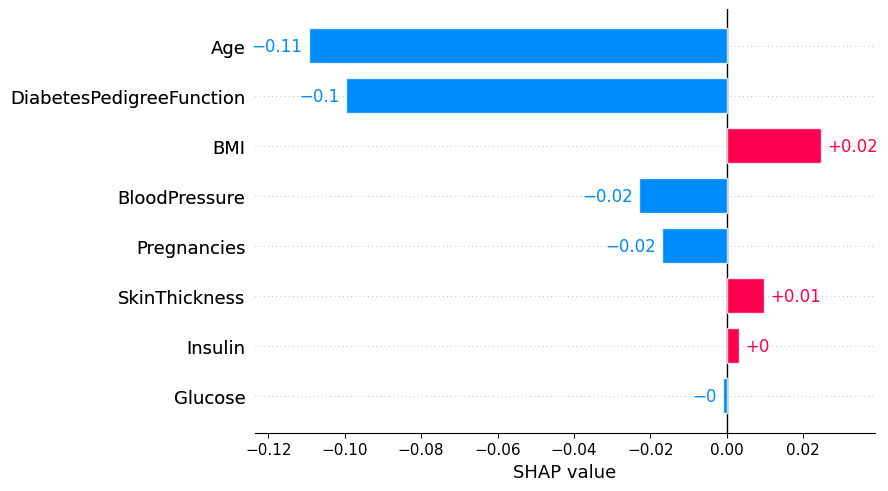

In [30]:
shap.plots.bar(
    shap.Explanation(
        values=reference_explanations[0],
        feature_names=df.columns[:-1],
    ), 
    max_display=20
)

In [31]:
N_POP = 50
N_GEN = 10

P_ELITE = 0.04
P_COMBINE = 0.05

In [32]:
initial_mutation_rate = 15 / (0.01 * X_train.shape[0] * X_train.shape[1])
initial_mutation_rate

0.3053745928338762

In [33]:
initial_population = init_population(
    reference_data=X_train,
    cat_mask=[False]*X_train.shape[1],
    population_size=N_POP,
    initial_mutation_rate=initial_mutation_rate,
)

In [34]:
best_individuals, best_fitnesses, best_generation, logging = evolve_population(
    initial_population = initial_population,
    explainer = explainer,
    reference_explanations = reference_explanations,
    n_generations = N_GEN,
    elite_prop = P_ELITE,
    p_combine = P_COMBINE,
    X_min = X_min,
    X_max = X_max,
    X_cat = [None]*X_train.shape[1]
)

Concatenating population took 0.0 seconds.
Producing SHAP explanations for the population took 76.75163125991821 seconds.
Repeating reference explanations took 0.0 seconds.
Calculating explanation losses for the population took 10.28374433517456 seconds.
Calculating mean losses and fitnesses took 0.0 seconds.
Initial Population - Best Fitness: 0.956003 --- Time: 87.04s
before evolution --- Time: 87.04s
--- produced next generation --- Time: 87.06s
Concatenating population took 0.0 seconds.
Producing SHAP explanations for the population took 73.61100101470947 seconds.
Repeating reference explanations took 0.0 seconds.
Calculating explanation losses for the population took 10.279745817184448 seconds.
Calculating mean losses and fitnesses took 0.0 seconds.
--- calculated fitnesses --- Time: 170.95s
Generation 1/10 - Best Fitness: 0.956003
--> completed generation --- Time: 170.95s
--- produced next generation --- Time: 170.97s
Concatenating population took 0.0 seconds.
Producing SHAP expl

In [35]:
best_fitnesses

[np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842),
 np.float64(0.9560026386814842)]

In [36]:
[best_individual.mutation_rate for best_individual in best_individuals]

[np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169),
 np.float64(0.2141156598705169)]

In [37]:
fitnesses = [log[0] for log in logging]
fitnesses

[array([0.90338924, 0.90999783, 0.90675381, 0.9049542 , 0.93941084,
        0.93483847, 0.92581834, 0.93711727, 0.93032503, 0.92024763,
        0.94713331, 0.94551808, 0.89306863, 0.92502308, 0.92805312,
        0.95600264, 0.93609211, 0.91799618, 0.90574448, 0.92119631,
        0.91769074, 0.93420633, 0.91363298, 0.90178465, 0.91739743,
        0.93455367, 0.92502134, 0.94883658, 0.93658311, 0.93662148,
        0.92826534, 0.93559313, 0.94295605, 0.93243475, 0.94719193,
        0.91644107, 0.92530914, 0.90503199, 0.91420019, 0.92314091,
        0.9367724 , 0.9127183 , 0.92255994, 0.93487357, 0.92447187,
        0.92972895, 0.92438945, 0.9117875 , 0.92159239, 0.92294282]),
 array([0.95600264, 0.94883658, 0.90498192, 0.89812372, 0.88262932,
        0.86267931, 0.87684346, 0.89193749, 0.86871207, 0.88058316,
        0.90305996, 0.87742692, 0.88610387, 0.81394512, 0.87268619,
        0.88527584, 0.8697576 , 0.86066027, 0.86863168, 0.79998894,
        0.90019745, 0.89707308, 0.88171479, 0.

In [38]:
fitnesses[0].max()

np.float64(0.9560026386814842)